# AIO Q1 -- Data Analysis and Visualization
In this test we will look at some real world data and do some data analysis and visualizations

## 0 -- imports
Here are the libraries that you are allowed to use for this problem

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

## 1 -- Dataloading (5)
First we must load the data from the attached csv, 'data_by_zip.csv' which contains a complex US energy dataset. You should open the CSV to get a sense of the data, though it will be too large for you to fully read.  (This data is taken from this paper: https://dl.acm.org/doi/10.1145/3679240.3734603 -- you may look it over another time if you are curious)

In [95]:
# TODO Load the csv data into a pandas dataframe -- then print out the dimensions of the data.
df = pd.read_csv('data_by_zip.csv')
print(df.shape)

(10544, 42)


## 2 -- Data Cleaning (10)
Now we will clean our data by removing NA values and outliers.

In [96]:
# TODO First, replace all NA values (i.e. missing values) with 0
df = df.fillna(0)
print(df)

       zipcode   state_name  yearly_sunlight_kwh_kw_threshold_avg  \
0          603    Aguadilla                           1159.196895   
1          612      Arecibo                           1113.714302   
2          646       Dorado                           1101.567016   
3          660  Hormigueros                           1107.064952   
4          676         Moca                            996.200000   
...        ...          ...                                   ...   
10539    99518       Alaska                            742.900000   
10540    99701       Alaska                            687.650000   
10541    99703       Alaska                            687.650000   
10542    99709       Alaska                            687.650000   
10543    99712       Alaska                            687.650000   

       yearly_sunlight_kwh_total  existing_installs_count  percent_covered  \
0                   1.349544e+08                      0.0        85.210869   
1              

In [97]:
# TODO Then, for each column with numeral entries remove all rows whose value in that column is more than 3 stardard deviations from the mean of the column.
# A row should be removed from the dataset if it is an outlier in *any* column
n_cols = df.select_dtypes(include=[np.number]).columns
for cola in n_cols:
  x = df[cola]
  mu = df[cola].mean()
  stand = df[cola].std()
  oog = (x - mu)/stand
  df[cola] = oog
print(df)

        zipcode   state_name  yearly_sunlight_kwh_kw_threshold_avg  \
0     -1.589549    Aguadilla                              0.674800   
1     -1.589249      Arecibo                              0.321633   
2     -1.588116       Dorado                              0.227311   
3     -1.587649  Hormigueros                              0.270002   
4     -1.587116         Moca                             -0.590851   
...         ...          ...                                   ...   
10539  1.707574       Alaska                             -2.557696   
10540  1.713674       Alaska                             -2.986705   
10541  1.713740       Alaska                             -2.986705   
10542  1.713940       Alaska                             -2.986705   
10543  1.714040       Alaska                             -2.986705   

       yearly_sunlight_kwh_total  existing_installs_count  percent_covered  \
0                      -0.028324                -0.363861         0.215042   
1  

In [98]:
# TODO After this step you should save this dataframe as a csv named 'clean_data_by_zip.csv'
df.to_csv('clean_data_by_zip.csv')

## 3 -- Simple Scatter Plot (10)
We will do an initial visualization of some of the features of out data.

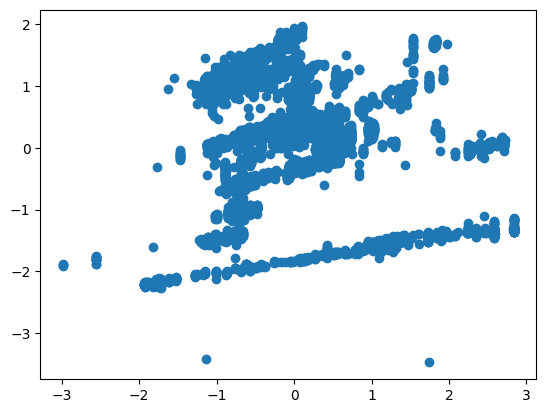

In [103]:
# TODO Create a scatter plot where each row (i.e. Zipcode) is a point with the following axes:
# X axis: The value corresponding to the 'yearly_sunlight_kwh_kw_threshold_avg' key -- this is the amount of energy (kWh) produced in an average year by a 1 kW solar panel in that Zipcode
# Y axis: The value corresponding to the 'carbon_offset_metric_tons_per_panel' key -- this is the amount of CO2 that would not be emitted for every kWh of energy produced via clean energy.
# Axes should be labelled appropriately and a title should be given.

cdf = pd.read_csv('clean_data_by_zip.csv')
fig, ax = plt.subplots()
ax.scatter(cdf['yearly_sunlight_kwh_kw_threshold_avg'], cdf['carbon_offset_metric_tons_per_panel'])

plt.show()

In [ ]:
# TODO Modify your plot such that the ZipCodes from California are all in a different color.

In [ ]:
# TODO Further modify your plot such that there is a vertical dotted line (gray with alpha = 0.5) showing the average yearly sunlight value
# And a similar horizontal line for the y axis average.

## 4 -- Generalized Scatter plot (10)
Now we will write a function that can generalize this to arbitrary keys and subsets of the dataset.

In [ ]:
# Complete the following plotting function, instructions are given via the comment

def scatter_plot(x_values, y_values, stats_line=None, masks=None):
    '''
    Params:
    x_values: values to be plotted on the x axis
    y_values: values to be plotted on the y axis
    stats_line: Determines the type of stat line to add to the plot (None wil plot nothing, 'mean' will add mean lines as above, 'median' will add a line for the median on each axis)
    masks: A list of tuples, with each tuple (i.e. each mask) having 3 elements:
        1. A binary mask (i.e. np Array) of the same length as the data where 1 corresponds to the data point at that index being included and 0 to it being exluded
        2. A name to add to the legend for this subset (e.g. 'CA Zipcodes')
        3. A color for those datapoints to be set to.

    '''

    pass


In [ ]:
# TODO Show that your function works by reproducing your plot from above using a call to this function

In [ ]:
# TODO show that it works with other values by producing a new graph plotting 'Total_Population' versus 'existing_installs_count'
# With lines showing the median drawn
# And with CA zipcodes drawn in green and MA zipcodes drawn in black.

## 5 -- Complex Scatters/polynomial fits (30)
Now we will modify our code to include polynomial fits to our masked subsets. Doing only a linear fit will give 50% credit on this part.

In [ ]:
# TODO modify your above code such that a new element is added to your 'masks' tuples as explained below

def complex_scatter_plot(x_values, y_values, stats_line=None, masks=None):
    '''
    Modification: Add a 4th element to each mask tuple which is an integer representing the degree of fit to be shown.
    E.G. if a tuple is : ([0,1,0,1, ...], 'Even data', 'blue', 5) then there should be a 5 degree polynomial fit of the data corresponding to the mask
    added to the plot, it should be the same color as the data itself but with alpha=0.5.
    '''
    pass

In [ ]:
# TODO show that your code works by showing the plots from part 4 with each mask having a 4 degree polynomial fit. Show only linear fits if that is the only fit completed.

## 6 -- Pearson Correlation (10)
We will now implement a pearson correlation calculation for any two sets of values. The Pearson correlation coefficient intuitively represents how closesly two sets, X and Y, are to a purely linear relationship (i.e. Y = w * X + b, for some w and b) with value 1 meaning a perfect linear fit and 0 meaning completely uncorrelated data.
<\br><\br>
Specifically Pearson Correlation Coefficient (PCC) is calculated like so:
\begin{align*}
PCC(X,Y) = \frac{cov(X,Y)}{\sigma_X \sigma_Y}
\end{align*}
Where,
\begin{align*}
cov(X,Y) = \mathbb{E}[(X - \mu_X)(Y - \mu_Y)]
\end{align*}
With: $\mu_X$ is the average of X and $\sigma_X$ is the standard deviation of X.


In [ ]:
# TODO complete the implementation of Pearson Correlation

def pearson_corr(X, Y):

    pass

In [ ]:
# TODO report the pearson correlation of the following pairs:

'''
total population vs existing installs:
    - In all ZIP codes
    - In CA ZIP codes
    - In MA ZIP codes

Median Income (find the exact key in the csv) vs installs per capita (existing installs / population of each ZIP)
    - In all ZIP codes
    - In CA ZIP codes
    - In MA ZIP codes

'''

## 7 -- Pearson correlation heatmap (15)
Now we will use our pearson correlation calculations to produce heatmaps for data analysis

In [ ]:
# TODO complete the heatmap function below

def pearson_heatmap(dataframe, keys):
    '''
    dataframe: a Pandas Dataframe of zip codes -- this will either be the entire dataset from the csv, or some subset.
    keys: a list of keys (i.e. col of the dataframe) which we will find the p-corr between.

    This should plot a heatmap (via seaborn) the pearson correlation between each pair of keys.
    For the scale of the heatmap color you should show all p-corr(x,x) (i.e. the p-corr between a col and itself) to be the average of all other (non symmetric) correlations
    '''

pass

In [ ]:
# TODO use this to show the pearson correlations of the following keys

keys = ['Median_income', 'existing_installs_count', 'black_prop', 'asian_prop', 'yearly_sunlight_kwh_kw_threshold_avg', 'carbon_offset_metric_tons', 'Total_Population']

# For: all the zips, just CA zips, just MA zips, and just MI zips -- that is 4 heatmaps

In [ ]:
# TODO: Additionally, for each state-specific heatmap show the different of the heatmap to the all ZIP heatmap (that is, a new heatmap with the diagnoal entries = 0)
# And report the correlation entry which is most different for each of these states compared to the full dataset.

## 8 -- Conclusion Analysis (10)
Now, using all of the results that you've visualized, make some conclusions -- you are graded here based on the correctness of your conclusion and how compelling the argument you make is.

#### 8a. If the intention of installing solar panels is to both increase energy generation and carbon offset how good is the current distribution of panels?

#### 8b. If you were to add n new solar panels in zip codes of your choosing how would you decide where to put them if attempting to co-maximize energy generation and carbon offset?

## END OF MOCK AIO QUESTION --------------------------------------------------------
Below are some extention questions for interested students. In particular, this is the begininng of my recent research work (1st paper is: https://dl.acm.org/doi/10.1145/3679240.3734603, 2nd is here: https://dl.acm.org/doi/pdf/10.1145/3736425.3770115, 3rd is being published soon but I can share it if you are interested). If any of you are interested and able to work on this effectively then I would consider a research mentorship to help on the 4th/5th paper in the series and perhaps earn authorship.
</br></br>
You may reference the library I created for these works (you can also find implementations of the problem you just did in it) here: https://github.com/coopersigrist/SunSight
</br></br>
If you finish all of these problems with high competency I will almost definitely take you on for the next paper and give you an authorship position.

### EX 1. Find 3 other notable and relevant statistics from this data -- You may use any techniques.

### EX 2. Create an algorithm which places n panels in zip codes with the goal to maximize energy generation and carbon offset. Give pseudo-code for your algorithm and show a map of the locations that 2 million panels would be placed (I recommend using the visualization in the SunSight library)

### EX 3. Use the Sunsight library to create a projection of the success of your model in Carbon Offset and Energy Generation (like fig 6 + 7 in paper 1) compared to the baselines of the paper.

### EX 4. Using the SunSight library replicate the results from the second paper (EVA implementation), namely fig 3 + 4

### (*) EX 5. Modify the EVA method from paper 2 such that instead of placing panels in the highest value ZIPs it instead stochastically places them based on the Soft Max of the scores for all ZIP codes. Report the results

### (**) EX 6. Modify the implementation of EVA further such that each objective is decomposed to be 50 objectives (1 for each state) -- that is, instead of having a national energy generation score, there should be 1 per state and the lexicase selection should choose some subsection of all of these objectives to use to select the surviving models in each iteration of NEAT. (If you end up working on this one I can meet with you briefly to explain if this is unclear).